In [1]:
import pandas as pd
import os,sys,warnings
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from Bio import SeqIO
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform
from scipy.stats import spearmanr
from collections import Counter
from matplotlib.lines import Line2D
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from matplotlib.patches import FancyArrowPatch

warnings.filterwarnings("ignore")
os.chdir('/Users/houlin/Desktop/Research/Ecohab/Ecohab22/metatranscriptoms')
path=os.getcwd()
plt.style.use('default')
sys.path.append(os.path.abspath('/Users/houlin/Desktop/Research/Ecohab/Ecohab22/code'))

metadata=pd.read_csv('/Users/houlin/Desktop/Research/Ecohab/Ecohab22/data/Ecohab22_metadata_082324.csv')
metadata1=metadata
metadata=metadata[~metadata['sample-id'].str.contains('EH15|EH16')]

cpl_unfiltered_tax_full=pd.read_csv('CPL/EcoHAB22-CPL-norm-annotated-unfiltered-taxfull.csv',index_col=0)
cpl_filtered_tax_full=pd.read_csv('CPL/EcoHAB22-CPL-norm-annotated-filtered-taxfull.csv',index_col=0)
cpl_clustered_tax_full_filtered=pd.read_csv('CPL/EcoHAB22-CPL-norm-clustered-filtered-taxfull.csv',index_col=0)

df_raw=pd.read_csv('EcoHAB22_dab_ISIP_nitrogen_070224.csv')
dab_genes=pd.read_excel(f'{path}/dab_genes/dab_genes_v1.xlsx')
nitrogen_genes=pd.read_csv('/Users/houlin/Desktop/Ecohab/Ecohab22/metatranscriptoms/Nitrogen_genes/nitrogen_gene.csv')
df_tax_full=pd.read_csv('Ecohab22_meta_taxfull_070524.csv',index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/houlin/Desktop/Ecohab/Ecohab22/metatranscriptoms/Nitrogen_genes/nitrogen_gene.csv'

In [ ]:
metadata_da=pd.read_csv('/Users/houlin/Desktop/Ecohab/Ecohab22/data/Ecohab22_metadata_DA.csv')

In [ ]:
def sumindex(df,col,percent):
    #percent True or False: if you want to make the results relative abundace to each other
    df=df.dropna(subset=col)
    df_index=df.set_index(col).iloc[:,3:66]
    df_index=rank_by_mean(df_index.groupby(df_index.index).sum())
    if percent:
        df_index=calculate_percentage(df_index)*100
    return df_index

def genename_df(df,genus,db,range_define):
# genus is False-> all, or specify the genus
# db= 'Pfam_description, KO_description,...Pfam, KO
    if not genus:
        df=df
    else:
        df=df[df.LPI_taxonomy.str.contains(genus,na=False)]
    df_dab = df.dropna(subset=['dab_gene'])
    df_ISIP = df.dropna(subset=['ISIP_gene'])
    df_nitrogen = df.dropna(subset=['N_genes'])
    df_sit = df.dropna(subset=['SiLA_gene'])
    if range_define in ['tpm','cpl']:
        df_dab=df_dab.iloc[:,3:66].groupby(df_dab['dab_gene']).sum()
        df_ISIP=df_ISIP.iloc[:,3:66].groupby(df_ISIP['ISIP_gene']).sum()
        df_nitrogen = df_nitrogen.iloc[:,3:66].groupby(df_nitrogen['N_genes']).sum()
        df_sit=df_sit.iloc[:,3:66].groupby(df_sit['SiLA_gene']).sum()
    else:
        df_dab=df_dab.iloc[:,0:63].groupby(df_dab['dab_gene']).sum()
        df_ISIP=df_ISIP.iloc[:,0:63].groupby(df_ISIP['ISIP_gene']).sum()
        df_nitrogen= df_nitrogen.iloc[:,0:63].groupby(df_nitrogen['N_genes']).sum()
        df_sit=df_sit.iloc[:,0:63].groupby(df_sit['SiLA_gene']).sum()

    df_filter=df.dropna(subset=[db])
    df_filter=df_filter[~df_filter[db].str.contains('unknown',case=False)]
    if range_define in ['tpm','cpl']:
        df_pfam=df_filter.iloc[:,3:66].groupby( df_filter[db]).sum()
    else:
        df_pfam=df_filter.iloc[:,0:63].groupby( df_filter[db]).sum()
    df_sum= pd.concat([df_dab, df_ISIP,df_nitrogen,df_sit,df_pfam], axis=0, ignore_index=False)
    return df_sum

def dominated_genes(df):
# Condition 1: Mean of the row is greater than 1
    condition1 = df.mean(axis=1) > 0.1
    # Condition 2: Any column entry in the row is greater than 5
    condition2 = df.max(axis=1) > 1
    # Combine the conditions
    combined_condition = condition1 | condition2
    # Record the index of the rows that meet either condition
    filtered_indices = df.index[combined_condition]
    return pd.DataFrame(filtered_indices.tolist(),columns=['Genes'])

def rank_by_mean(df):
    df_ranked = df.loc[df.mean(axis=1).sort_values(ascending=False).index]
    return df_ranked
#finding dominanted cells
def dominated_tax(df):
# Condition 1: Mean of the row is greater than 1
    condition1 = df.mean(axis=1) > 1
    # Condition 2: Any column entry in the row is greater than 5
    condition2 = df.max(axis=1) > 5
    # Combine the conditions
    combined_condition = condition1 | condition2
    # Record the index of the rows that meet either condition
    filtered_indices = df.index[combined_condition]
    return pd.DataFrame(filtered_indices.tolist(),columns=['Tax'])

def spearman_corr_pvalues(df):
    rho = pd.DataFrame(np.zeros((df.shape[1], df.shape[1])),
                       columns=df.columns, index=df.columns)
    pval = pd.DataFrame(np.ones((df.shape[1], df.shape[1])),
                        columns=df.columns, index=df.columns)
    for col in df.columns:
        for row in df.columns:
            if col != row:
                valid_idx = df[[col, row]].dropna().index
                rho[col][row], pval[col][row] = spearmanr(df.loc[valid_idx, col], df.loc[valid_idx, row])
            else:
                rho[col][row] = 1.0
                pval[col][row] = np.nan  # For the same variables, we set NaN
    return rho, pval
from scipy.stats import spearmanr

def extract_gene_names(fasta_file):
    gene_names = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        gene_names.append(record.id)
    return gene_names

def calculate_percentage(df):
    # Calculate the sum of each column, axis=0 is column
    column_sums = df.sum(axis=0) 
    # Divide each element by its column sum and multiply by 100 to get percentage
    percentages_df = df.div(column_sums, axis=1) 

    return percentages_df

def normalize_rows(data):
    colnames = data.columns.tolist()
    rownames = data.index.tolist()
    normalized_data = np.zeros_like(data, dtype=float)
    num_rows, num_cols = data.shape
    for i in range(num_rows):
        normalized_data[i] = (data.iloc[i] - np.min(data.iloc[i])) / (np.max(data.iloc[i])-np.min(data.iloc[i]))
    normalized_data=pd.DataFrame(normalized_data)
    normalized_data.columns=colnames
    normalized_data.index=rownames
    return normalized_data

def averaging_expression(expression,metadata_used,round_num,metadata):
    df_mean=expression
    if metadata_used=='sample-id':
        df_mean_normalized=normalize_rows(df_mean)
    else:
        metadata=metadata.set_index('sample-id')
        if metadata_used in ['Date','group_chl','Phase_group','Geo_group','diatom_group','Eu_group']:
            df_mean.columns=metadata.loc[df_mean.columns,metadata_used]
        elif metadata_used in ['Depth']:
            df_mean.columns=round(metadata.loc[df_mean.columns,metadata_used])
        else:
            df_mean.columns=round(metadata.loc[df_mean.columns,metadata_used],round_num)
        df_mean=df_mean.sort_index(axis=1)
        df_T = df_mean.T
        # Group by the index (original column names) and sum
        df_grouped = df_T.groupby(df_T.index).mean()
        # Transpose back to the original orientation
        df_mean = df_grouped.T
        df_mean_normalized=normalize_rows(df_mean)
    return df_mean, df_mean_normalized

def count_tax(filtered_gene_df):
    #df_l7=gene_df.set_index('L7')
    filtered_gene_df=pd.DataFrame(filtered_gene_df)
    #df_l7=df_l7.iloc[:,3:66] filtering the dataframe to keep only the samples, not NC or PC
    a=pd.DataFrame(filtered_gene_df.sum(axis=1))
    a=a.groupby(a.index).sum()
    totalcount=a.sum()[0]
    a.columns=['counts']
    percent=[x/totalcount for x in a.counts]
    a['percent']=percent

    a.reset_index(drop=False, inplace=True)
    a.columns = ['tax', 'counts', 'percent']
    sorted_a=a.sort_values(by='counts',ascending=False)
    return sorted_a

def jaccard_index(df):
    species = df.columns
    jaccard = pd.DataFrame(index=species, columns=species, dtype=float)
    for i in species:
        for j in species:
            if i != j:
                intersection = np.sum(df[i] & df[j])
                union = np.sum(df[i] | df[j])
                jaccard.loc[i, j] = intersection / union
            else:
                jaccard.loc[i, j] = 1.0
    return jaccard

# Fisher's exact test for significant co-occurrence
def fisher_test(df):
    species_pairs = list(itertools.combinations(df.columns, 2))
    p_values = {}
    for (species1, species2) in species_pairs:
        contingency_table = pd.crosstab(df[species1], df[species2])
        if contingency_table.shape == (2, 2):
            _, p_value = fisher_exact(contingency_table)
            p_values[(species1, species2)] = p_value
    return p_values


def adding_taxes(df,taxlevel,df_match,type): 
    l2names=[]
    l4names=[]
    l3names=[]
    l5names=[]
    l6names=[]
    for taxname in df.Tax:

        condition = df_match.isin([taxname])
        # Locate the rows that contain 'A'
        a = df_match.loc[condition.any(axis=1)]
        l2names.append(a.L2.iloc[0]) 
        l3names.append(a.L3.iloc[0])
        l4names.append(a.L4.iloc[0])
        l5names.append(a.L5.iloc[0])
        l6names.append(a.L6.iloc[0])
    if taxlevel=='L8':
        df['L6']=l6names
        df['L5']=l5names
        df['L4']=l4names
        if type!='Eu':
            df['L3']=l3names
            df['L2']=l2names
    elif taxlevel=='L6':
        if type!='Eu':
            df['L4']=l4names
            df['L3']=l3names
            df['L2']=l2names
        else:
            df['L4']=l4names
            df['L5']=l5names
    elif taxlevel=='L4':
        df['L3']=l3names
        df['L2']=l2names
    elif taxlevel=='L3':
        df['L2']=l2names
    return df

def displaying_upperlevel(df,taxlevel,df_match):
    df_l3=df.loc[:,['mean_corr','mean_pval','corr_tax','frequency',taxlevel]]
    df_results= df_l3.groupby(df_l3[taxlevel]).agg({
    'mean_corr': 'mean',  # Mean of numerical column B
    'mean_pval': 'mean',  # Mean of numerical column C
    'corr_tax': aggregate_strings,  # Concatenate strings in column D
    'frequency':'sum'
    }).reset_index()
    df_results.columns=['Tax','mean_corr','mean_pval','corr_tax','frequency']
    df=df_results.sort_values(by='frequency',ascending=False)
    df_final=adding_taxes(df,taxlevel,df_match,'all')
    return df_final

def clr_transformation_df(df):
    df=df.replace(0,1e-10)
    clr_transformed = clr(df.T)
    # Convert back to a dataframe for easier handling
    clr_df = pd.DataFrame(clr_transformed, index=df.columns, columns=df.index).T
    clr_corr_matrix = clr_df.T.corr(method='corr_method')
    rho,pval=spearman_corr_pvalues(clr_df.T)
    return clr_df,clr_corr_matrix,rho,pval



1.Dab gene analysis

In [6]:
import json
with open('pfam_genename_dict.txt', 'r') as file:
    pfam_genename_dict = json.load(file)

#['cell_death', 'cell_cycle', 'cyclin', 'glycolysis', 'b12',
#  'chloroplast', 'photosynthesis',
#  'iron_uptake', 'low_iron', 'nitrogen_gene', 'dab', 
#  'urea_cycle', 'glycerolipid', 'glycerolipid_dia', 
#  'ammoninum_assimilation', 'calvin_cycle']

In [7]:
savepath='/Users/houlin/Desktop/Ecohab/Ecohab22/Paper_ISME/Raw_figures'

In [32]:
tax_name='Pseudo-nitzschia'
dataused='sample-id'
df=cpl_unfiltered_tax_full
db=pfam_genename_dict
name=f'{tax_name} Iron Uptake and Metabolism'

cpl_df=genename_df(df,tax_name,'MCL_anno','cpl') #'Bacillariophyta' 'Mamiellophycea'
cpl_df=cpl_df.drop(index=['GSIIA','GSIII','NRT2','Low iron-inducible periplasmic protein'])
cpl_df_relative=calculate_percentage(cpl_df)*100

gene_used=set(db['dab_gene']+db['low_iron']+db['iron_uptake']+db['nitrogen_gene']+db["silicon"]) 

df_gene= cpl_df[cpl_df.index.str.contains('|'.join(gene_used), case=True)]
df_gene_relative=cpl_df_relative[cpl_df_relative.index.str.contains('|'.join(gene_used), case=True)]

metadata_sample=metadata.set_index('sample-id')
a=pd.DataFrame(df_sample.sum())
metadata_sample['pn_cpl']=a.loc[metadata_sample.index,:]
metadata_sample['DA_per_cpl']=metadata_sample.DA/metadata_sample.pn_cpl


datakeep=['dabA','dabC','Silicon transporter','flavodoxin I', 
      'ISIP2A','ISIP1','NR','Silicon transporter','SiLA12']#'Chlorophyll A-B binding protein', 
#datakeep=['dabA','dabD','dabC']
df=df_gene_relative.loc[datakeep]
df1=df_gene.loc[datakeep]
metadata_sample=pd.concat([metadata_sample,df1.T],axis=1)

# metadata_sample['dabA_cpl_r']=df_gene_relative.loc['dabA', metadata_sample.index]
# metadata_sample['dabC_cpl_r']=df_gene_relative.loc['dabC', metadata_sample.index]
# metadata_sample['dabD_cpl_r']=df_gene_relative.loc['dabD', metadata_sample.index]
# metadata_sample['SET_cpl_r']=df_gene_relative.loc['Silicon transporter', metadata_sample.index]
# metadata_sample['Flavodoxin_cpl_r']=df_gene_relative.loc['Flavodoxin', metadata_sample.index]
# metadata_sample['ISIP2A_cpl_r']=df_gene_relative.loc['ISIP2A', metadata_sample.index]

metadata_sample_filtered = metadata_sample.sort_values(by='pn_cpl').iloc[:-2]

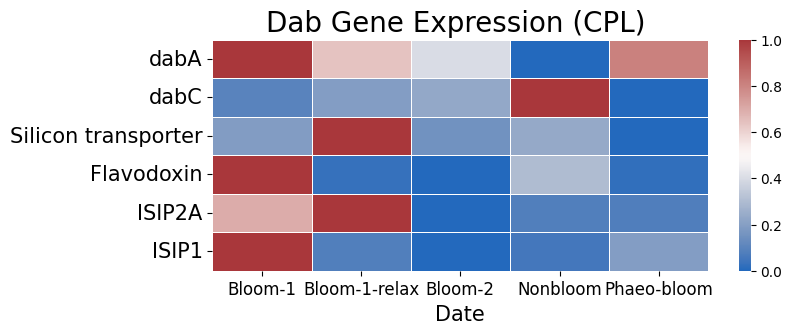

In [68]:
from matplotlib.colors import BoundaryNorm
df_sample=df
datause='Phase_group'
df_mean,df_norm=averaging_expression(df_sample,datause,2,metadata)

boundaries= np.array([0,0.01, 0.02, 0.05, 0.1, 0.2, 0.4, 0.8, 1.2, 1.6])*1e7
norm_da = BoundaryNorm(boundaries, ncolors=256)

if datause=='sample-id':
    a=metadata.set_index('sample-id')
    df_mean.columns=a.loc[df_mean.columns,'Date']
    df_mean=df_mean.sort_index(axis=1)
    df_norm.columns=a.loc[df_norm.columns,'Date']
    df_norm=df_norm.sort_index(axis=1)
    
    
plt.style.use('default')
fig=plt.figure(figsize=(8,3)) 
sns.heatmap(df_norm,#norm=norm_da,
              cmap="vlag", fmt=".1f", linewidths=.5)

plt.title('Dab Gene Expression (CPL) ',fontsize=20)
plt.xlabel('Date',fontsize=15)
plt.xticks(rotation=0,fontsize=12)
plt.yticks(fontsize=15,rotation=360)
fig.savefig(f'{savepath}/dab_heatmaps_norm.svg')
plt.show()


In [34]:


df=metadata_sample.loc[:,datakeep+['pn_cpl','Mean_Salinity','Mean_Temp','Mean_Chl']] #,'Mean_Salinity','Mean_Temp','Mean_Chl'
#df_corr=df.corr(method='spearman')
df = df.rename(columns={'flavodoxin I': 'Flavodoxin'})
df = df.rename(columns={'pn_cpl': 'PN Abundance'})
print(len(df))
#rho,pval=spearman_corr_pvalues(df[~df.DA.isna()])
rho,pval=spearman_corr_pvalues(df)
fig=plt.figure(figsize=(8, 7)) 
plt.style.use('default')

#rho=rho.replace(1,np.nan)
ax = sns.heatmap(rho, annot=False, fmt=".2f", cmap="vlag")

# Add asterisks to significant values
for i in range(rho.shape[0]):
    for j in range(rho.shape[1]):
        if pval.iloc[i, j] < 0.05:
            ax.text(j+0.5, i+0.6, "*", color='black', ha='center', va='center', fontsize=12)

plt.title('Spearman Correlation, n=63',fontsize=20)
plt.yticks(fontsize=15,rotation=360)
plt.xticks(fontsize=15,rotation=90)
figsave='/Users/houlin/Desktop/Ecohab/Ecohab22/Paper_ISME/Raw_figures'
fig.savefig(f'{figsave}/DA_spearman_heatmap.svg')
plt.show()

################# all data ###############################################################################################################################
df1=df_gene.loc[datakeep]
df1=df1.T
df1 = df1.rename(columns={'flavodoxin I': 'Flavodoxin'})

rho,pval=spearman_corr_pvalues(df1)
plt.figure(figsize=(6,5)) 
plt.style.use('default')

#rho=rho.replace(1,np.nan)
orig_map=plt.cm.get_cmap("RdYlBu") 
ax = sns.heatmap(rho, annot=False, fmt=".2f", 
                 cmap=orig_map.reversed(),vmin=-1,vmax=1)

# Add asterisks to significant values
for i in range(rho.shape[0]):
    for j in range(rho.shape[1]):
        if pval.iloc[i, j] < 0.05:
            ax.text(j+0.5, i+0.6, "*", color='black', ha='center', va='center', fontsize=15)
plt.title('Spearman Correlation, n=63',fontsize=20)
plt.yticks(fontsize=20,rotation=360)
plt.xticks(fontsize=20,rotation=90)
plt.show()


63


ValueError: cannot set using a list-like indexer with a different length than the value

In [35]:
df

,dabA,dabC,Silicon transporter,Silicon transporter,Flavodoxin,ISIP2A,ISIP1,NR,Silicon transporter,Silicon transporter,SiLA12,PN Abundance,Mean_Salinity,Mean_Temp,Mean_Chl
EH58_0325,8.845518e+05,4.422759e+05,1.254294e+07,1.254294e+07,2.466131e+07,3.697427e+07,3.290533e+06,3.184387e+05,1.254294e+07,1.254294e+07,0.0,2.459742,33.9905,11.624,1.77
EH57_0195,5.359827e+05,0.000000e+00,1.001037e+08,1.001037e+08,5.181166e+07,7.078545e+07,1.005861e+07,3.519620e+06,1.001037e+08,1.001037e+08,0.0,4.704655,33.9045,12.605,8.72
EH56_0250,3.314758e+06,0.000000e+00,7.709881e+07,7.709881e+07,2.654262e+08,1.242420e+08,1.436395e+07,2.209839e+06,7.709881e+07,7.709881e+07,0.0,3.927165,33.8996,12.319,9.16
EH55_0311,1.422584e+07,5.958795e+06,3.344452e+07,3.344452e+07,5.513454e+07,6.596073e+07,1.012368e+07,6.523313e+05,3.344452e+07,3.344452e+07,0.0,2.957547,33.8973,12.337,8.14
EH54_0212,9.183361e+06,7.314182e+05,1.341949e+07,1.341949e+07,2.676787e+07,6.618319e+07,7.364975e+06,0.000000e+00,1.341949e+07,1.341949e+07,0.0,1.743732,33.8937,12.457,11.26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
EH26_0142,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.771372e+05,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.0,3.237959,33.6938,16.291,2.98
EH24_0166,0.000000e+00,0.000000e+00,1.574164e+05,1.574164e+05,0.000000e+00,1.311803e+05,0.000000e+00,0.000000e+00,1.574164e+05,1.574164e+05,0.0,3.249056,33.6883,15.938,5.30
EH22_0169,0.000000e+00,0.000000e+00,2.242230e+07,2.242230e+07,2.379080e+06,1.894842e+06,0.000000e+00,0.000000e+00,2.242230e+07,2.242230e+07,0.0,2.941433,33.6804,15.594,3.49
EH20_0024,0.000000e+00,2.937150e+06,1.054361e+06,1.054361e+06,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.054361e+06,1.054361e+06,0.0,3.130971,33.6974,16.438,1.46


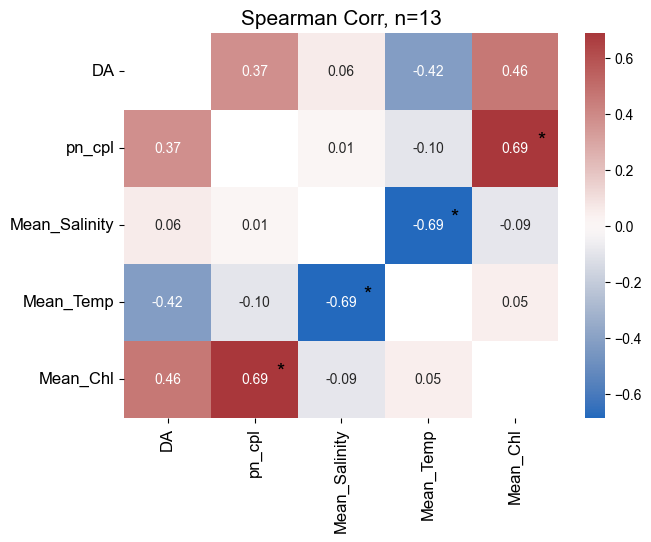

In [70]:
df=metadata_sample.loc[:,['DA','pn_cpl','Mean_Salinity','Mean_Temp','Mean_Chl']]
rho,pval=spearman_corr_pvalues(df)
plt.figure(figsize=(7, 5)) 
plt.rcParams['font.family'] = 'Arial'

rho=rho.replace(1,np.nan)
ax = sns.heatmap(rho, annot=True, fmt=".2f", cmap="vlag")
for i in range(rho.shape[0]):
    for j in range(rho.shape[1]):
        if pval.iloc[i, j] < 0.05:
            ax.text(j + 0.8, i + 0.4, "*", color='black', ha='center', va='center', fontsize=15)

#sns.heatmap(rho, cmap="vlag", fmt=".1f", linewidths=.5,annot=True)
plt.title('Spearman Corr, n=13',fontsize=15)
plt.yticks(fontsize=12,rotation=360)
plt.xticks(fontsize=12,rotation=90)
plt.show()


<Axes: >

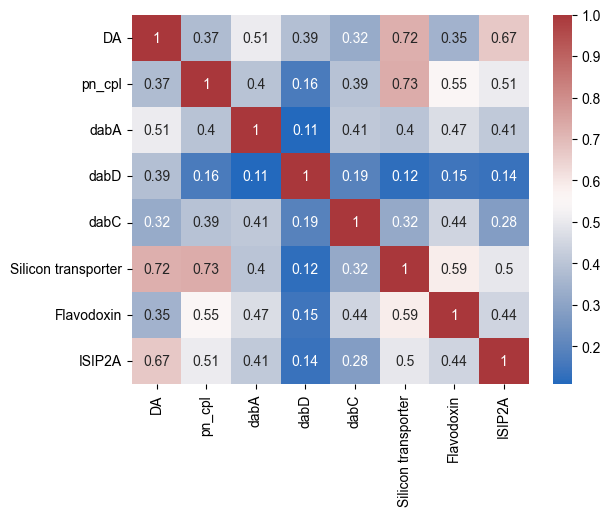

In [60]:
data=['DA','pn_cpl','dabA','dabD','dabC','Silicon transporter', 'Flavodoxin', 'ISIP2A']
df=metadata_sample.loc[:,data]
sns.heatmap(df.corr(method='spearman'),cmap='vlag',annot=True)

Text(0.5, 0, 'DA (ug/L)')

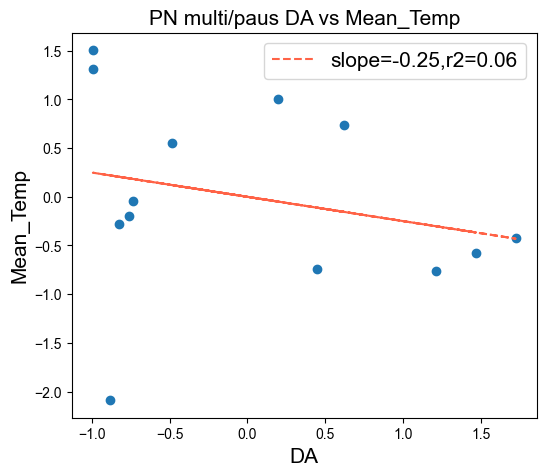

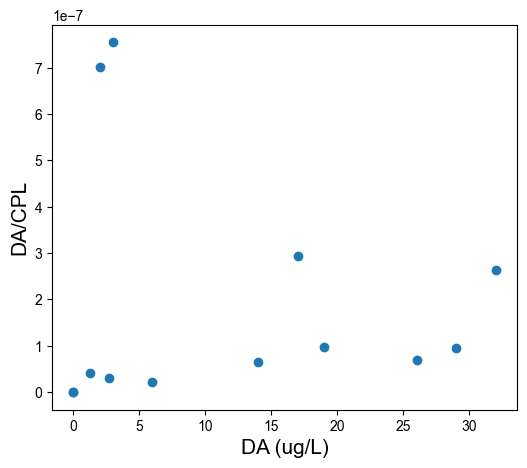

In [103]:
from scipy.stats import linregress
df=metadata_sample[~metadata_sample.DA.isna()]

#df=metadata_sample_filtered
ygeneuse='Mean_Temp'
xgeneuse='DA'
x=df[xgeneuse]
y=df[ygeneuse]
x=(x - x.mean()) / x.std()
y=(y - y.mean()) / y.std()
slope, intercept, r_value, p_value, std_err = linregress(x,y)
regression_line = slope * x + intercept
plt.figure(figsize=(6,5))
plt.scatter(x,y)
plt.plot(x, regression_line,linestyle='--', color='tomato', label=f'slope={slope:.2f},r2={r_value**2:.2f}')
plt.xlabel(xgeneuse,fontsize=15)
plt.ylabel(ygeneuse,fontsize=15)
plt.legend(fontsize=15,loc='best')
# cbar = plt.colorbar()
# cbar.set_label('pn_cpl', fontsize=15)
plt.title(f'PN multi/paus DA vs {ygeneuse}',fontsize=15)


plt.figure(figsize=(6,5))
plt.scatter(df.DA, df.DA_per_cpl)
plt.ylabel('DA/CPL',fontsize=15)
plt.xlabel('DA (ug/L)',fontsize=15)


2.Dabgene and annotation
1. dabA:Terpene synthase family 2, C-terminal metal binding (3)
2. dabC:non-haem dioxygenase in morphine synthesis N-terminal (2)
3. dabD:Cytochrome P450 (1)

In [85]:
df=cpl_filtered_tax_full
Counter(df[~df.dab_gene.isna()].MCL_anno)

Counter({'Terpene synthase family 2, C-terminal metal binding': 3,
         'non-haem dioxygenase in morphine synthesis N-terminal': 2,
         'Cytochrome P450': 1})